<a href="https://colab.research.google.com/github/PraeyOfTheGods/sephora-skincare-recommendation-week1-/blob/main/notebooks/04_predictive_modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## XGBoost Feature Importance Findings

XGBoost assigns overwhelmingly high importance to rating, with an importance value of approximately 0.999.

Price and skin type variables have very small importance values by comparison. This confirms that rating is the dominant predictor of recommendation in the current feature set.

The result should be interpreted cautiously because rating is closely associated with the recommendation outcome. Therefore, the model demonstrates strong prediction of review recommendation status, but it should not be interpreted as evidence that the model can make reliable recommendations before a customer has provided a rating.

In [32]:
xgb_feature_importance.to_csv(
    "/content/xgboost_feature_importance.csv",
    index=False
)

print("XGBoost feature importance saved.")

XGBoost feature importance saved.


In [31]:
xgb_feature_importance = pd.DataFrame({
    "feature": X_baseline.columns,
    "importance": xgb_model.feature_importances_
}).sort_values(
    "importance",
    ascending=False
)

xgb_feature_importance

,feature,importance
0,rating,0.998718
1,price_usd,0.000330
5,skin_type_normal,0.000254
2,skin_type_Unknown,0.000205
6,skin_type_oily,0.000171
4,skin_type_dry,0.000170
3,skin_type_combination,0.000152


## Final Model Comparison Findings

Three classification models were evaluated: Logistic Regression, Random Forest, and XGBoost.

All three models achieved very similar performance. Logistic Regression achieved the highest accuracy (0.9636) and precision (0.9913), while XGBoost achieved the highest ROC-AUC (0.9857). Random Forest achieved the highest recall (0.9658), although the difference was very small.

Since the performance differences are minimal, Logistic Regression remains a strong baseline because of its simplicity and interpretability. XGBoost provides a useful advanced-model comparison and achieves the highest ROC-AUC.

These results should be interpreted carefully because rating is included as a predictor of recommendation. Since rating is closely related to the recommendation outcome, the high predictive performance may partly reflect this strong relationship rather than genuine pre-purchase recommendation capability.

In [30]:
final_model_comparison.to_csv(
    "/content/final_model_comparison.csv",
    index=False
)

print("Final 3-model comparison saved.")

Final 3-model comparison saved.


In [29]:
final_model_comparison = pd.DataFrame({
    "model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "accuracy": [
        accuracy_score(y_test_base, y_pred_base),
        accuracy_score(y_test_base, y_pred_rf),
        accuracy_score(y_test_base, y_pred_xgb)
    ],
    "precision": [
        precision_score(y_test_base, y_pred_base),
        precision_score(y_test_base, y_pred_rf),
        precision_score(y_test_base, y_pred_xgb)
    ],
    "recall": [
        recall_score(y_test_base, y_pred_base),
        recall_score(y_test_base, y_pred_rf),
        recall_score(y_test_base, y_pred_xgb)
    ],
    "f1_score": [
        f1_score(y_test_base, y_pred_base),
        f1_score(y_test_base, y_pred_rf),
        f1_score(y_test_base, y_pred_xgb)
    ],
    "roc_auc": [
        roc_auc_score(y_test_base, y_prob_base),
        roc_auc_score(y_test_base, y_prob_rf),
        roc_auc_score(y_test_base, y_prob_xgb)
    ]
}).round(4)

final_model_comparison

,model,accuracy,precision,recall,f1_score,roc_auc
0,Logistic Regression,0.9636,0.9913,0.9651,0.9780,0.9852
1,Random Forest,0.9632,0.9901,0.9658,0.9778,0.9847
2,XGBoost,0.9635,0.9911,0.9653,0.9780,0.9857


In [28]:
y_pred_xgb = xgb_model.predict(X_test_base)
y_prob_xgb = xgb_model.predict_proba(X_test_base)[:, 1]

xgb_results = {
    "accuracy": accuracy_score(y_test_base, y_pred_xgb),
    "precision": precision_score(y_test_base, y_pred_xgb),
    "recall": recall_score(y_test_base, y_pred_xgb),
    "f1_score": f1_score(y_test_base, y_pred_xgb),
    "roc_auc": roc_auc_score(y_test_base, y_prob_xgb)
}

xgb_results

{'accuracy': 0.9635048708745986,
 'precision': 0.9910608259664864,
 'recall': 0.9652577876015216,
 'f1_score': 0.9779891410491778,
 'roc_auc': np.float64(0.9856580501829373)}

In [27]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss"
)

xgb_model.fit(X_train_base, y_train_base)

print("XGBoost model trained successfully")

XGBoost model trained successfully


## Feature Importance Findings

The Logistic Regression coefficients show that rating is the strongest predictor of recommendation, with a coefficient of 3.510.

The skin type variables also have relatively large coefficients, while price has a coefficient very close to zero (-0.0009), indicating limited influence on the prediction in this baseline model.

Because recommendation and rating are strongly related, the importance of rating should be interpreted carefully. This model is useful as a baseline for understanding review-level recommendation patterns, but rating would need to be excluded from a future pre-purchase recommendation model to avoid relying on information that would not be available before a customer provides a rating.

In [26]:
feature_importance.to_csv(
    "/content/logistic_feature_importance.csv",
    index=False
)

print("Feature importance saved.")

Feature importance saved.


In [25]:
feature_importance = pd.DataFrame({
    "feature": X_baseline.columns,
    "coefficient": logistic_baseline.coef_[0]
})

feature_importance["absolute_coefficient"] = (
    feature_importance["coefficient"].abs()
)

feature_importance = feature_importance.sort_values(
    "absolute_coefficient",
    ascending=False
)

feature_importance

,feature,coefficient,absolute_coefficient
0,rating,3.509960,3.509960
5,skin_type_normal,-1.899805,1.899805
4,skin_type_dry,-1.849418,1.849418
3,skin_type_combination,-1.815627,1.815627
6,skin_type_oily,-1.753371,1.753371
2,skin_type_Unknown,-1.734079,1.734079
1,price_usd,-0.000917,0.000917


## Confusion Matrix Findings

The Logistic Regression model correctly classified 28,338 reviews as Not Recommended and 150,194 reviews as Recommended.

There were 1,315 false positives and 5,438 false negatives. The relatively small number of false positives and false negatives supports the strong precision and recall observed in the model evaluation.

The confusion matrix also shows that the model performs well on the majority Recommended class, while the smaller Not Recommended class has comparatively fewer observations.

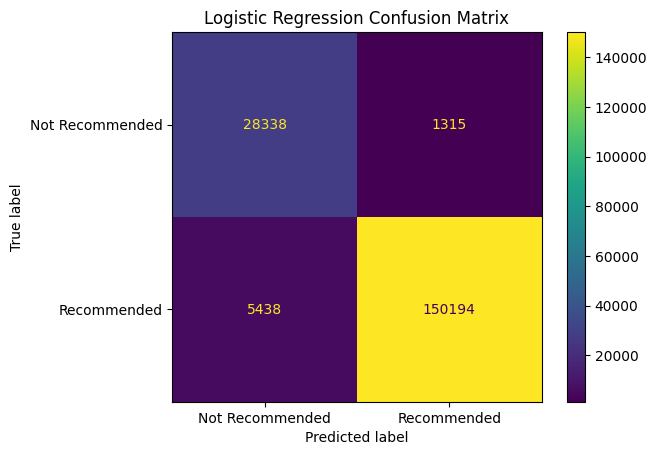

In [24]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test_base,
    y_pred_base,
    display_labels=["Not Recommended", "Recommended"]
)

plt.title("Logistic Regression Confusion Matrix")
plt.show()

## Model Comparison Findings

Logistic Regression and Random Forest produced very similar results.

Logistic Regression achieved a slightly higher accuracy (0.9636), precision (0.9913), F1-score (0.9780), and ROC-AUC (0.9852). Random Forest achieved a marginally higher recall (0.9658), but its overall performance was slightly lower.

Therefore, Logistic Regression is selected as the preferred baseline model because it provides strong predictive performance while remaining simpler and more interpretable.

In [23]:
final_model_comparison.to_csv(
    "/content/final_model_comparison.csv",
    index=False
)

print("Final model comparison saved.")

Final model comparison saved.


In [22]:
final_model_comparison = pd.DataFrame({
    "model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "accuracy": [
        accuracy_score(y_test_base, y_pred_base),
        accuracy_score(y_test_base, y_pred_rf)
    ],
    "precision": [
        precision_score(y_test_base, y_pred_base),
        precision_score(y_test_base, y_pred_rf)
    ],
    "recall": [
        recall_score(y_test_base, y_pred_base),
        recall_score(y_test_base, y_pred_rf)
    ],
    "f1_score": [
        f1_score(y_test_base, y_pred_base),
        f1_score(y_test_base, y_pred_rf)
    ],
    "roc_auc": [
        roc_auc_score(y_test_base, y_prob_base),
        roc_auc_score(y_test_base, y_prob_rf)
    ]
}).round(4)

final_model_comparison

,model,accuracy,precision,recall,f1_score,roc_auc
0,Logistic Regression,0.9636,0.9913,0.9651,0.9780,0.9852
1,Random Forest,0.9632,0.9901,0.9658,0.9778,0.9847


In [21]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

y_pred_rf = rf_model.predict(X_test_base)
y_prob_rf = rf_model.predict_proba(X_test_base)[:, 1]

rf_results = {
    "accuracy": accuracy_score(y_test_base, y_pred_rf),
    "precision": precision_score(y_test_base, y_pred_rf),
    "recall": recall_score(y_test_base, y_pred_rf),
    "f1_score": f1_score(y_test_base, y_pred_rf),
    "roc_auc": roc_auc_score(y_test_base, y_prob_rf)
}

rf_results

{'accuracy': 0.9631810454165205,
 'precision': 0.9901450573773731,
 'recall': 0.96577824611905,
 'f1_score': 0.9778098713870295,
 'roc_auc': np.float64(0.9846531544037601)}

In [20]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_base, y_train_base)

print("Random Forest model trained successfully")

Random Forest model trained successfully


## Predictive Modeling Baseline Findings

Two Logistic Regression baselines were evaluated for predicting whether a review was recommended.

The model using all selected features achieved a ROC-AUC of 0.9858, while the simpler baseline using rating, price, and skin type achieved a ROC-AUC of 0.9852. Accuracy, precision, recall, and F1-score were effectively identical between the two models.

This indicates that the additional feedback/helpfulness variables provided very limited improvement over the simpler feature set. The simpler baseline is therefore useful as an interpretable reference model for comparison with more advanced models.

In [19]:
model_comparison.to_csv(
    "/content/model_comparison.csv",
    index=False
)

print("Model comparison saved.")

Model comparison saved.


In [18]:
model_comparison = pd.DataFrame({
    "model": [
        "Logistic Regression - All Features",
        "Logistic Regression - Baseline Features"
    ],
    "accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test_base, y_pred_base)
    ],
    "precision": [
        precision_score(y_test, y_pred),
        precision_score(y_test_base, y_pred_base)
    ],
    "recall": [
        recall_score(y_test, y_pred),
        recall_score(y_test_base, y_pred_base)
    ],
    "f1_score": [
        f1_score(y_test, y_pred),
        f1_score(y_test_base, y_pred_base)
    ],
    "roc_auc": [
        roc_auc_score(y_test, y_prob),
        roc_auc_score(y_test_base, y_prob_base)
    ]
}).round(4)

model_comparison

,model,accuracy,precision,recall,f1_score,roc_auc
0,Logistic Regression - All Features,0.9636,0.9913,0.9651,0.978,0.9858
1,Logistic Regression - Baseline Features,0.9636,0.9913,0.9651,0.978,0.9852


In [17]:
print("Accuracy :", round(accuracy_score(y_test_base, y_pred_base), 4))
print("Precision:", round(precision_score(y_test_base, y_pred_base), 4))
print("Recall   :", round(recall_score(y_test_base, y_pred_base), 4))
print("F1-score :", round(f1_score(y_test_base, y_pred_base), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test_base, y_prob_base), 4))

print("\nClassification Report:")
print(classification_report(y_test_base, y_pred_base))

Accuracy : 0.9636
Precision: 0.9913
Recall   : 0.9651
F1-score : 0.978
ROC-AUC  : 0.9852

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.96      0.89     29653
           1       0.99      0.97      0.98    155632

    accuracy                           0.96    185285
   macro avg       0.92      0.96      0.94    185285
weighted avg       0.97      0.96      0.96    185285



In [16]:
logistic_baseline = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_baseline.fit(X_train_base, y_train_base)

y_pred_base = logistic_baseline.predict(X_test_base)
y_prob_base = logistic_baseline.predict_proba(X_test_base)[:, 1]

print("Cleaner baseline model trained successfully")

Cleaner baseline model trained successfully


In [15]:
baseline_features = [
    "rating",
    "price_usd",
    "skin_type_Unknown",
    "skin_type_combination",
    "skin_type_dry",
    "skin_type_normal",
    "skin_type_oily"
]

X_baseline = X[baseline_features].copy()

X_train_base, X_test_base, y_train_base, y_test_base = train_test_split(
    X_baseline,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Baseline features:", X_baseline.shape)
print("Training set:", X_train_base.shape)
print("Testing set:", X_test_base.shape)

Baseline features: (926423, 7)
Training set: (741138, 7)
Testing set: (185285, 7)


In [14]:
baseline_results.to_csv(
    "/content/baseline_model_results.csv",
    index=False
)

print("Baseline results saved.")

Baseline results saved.


In [13]:
baseline_results = pd.DataFrame({
    "model": ["Logistic Regression"],
    "accuracy": [accuracy_score(y_test, y_pred)],
    "precision": [precision_score(y_test, y_pred)],
    "recall": [recall_score(y_test, y_pred)],
    "f1_score": [f1_score(y_test, y_pred)],
    "roc_auc": [roc_auc_score(y_test, y_prob)]
})

baseline_results

,model,accuracy,precision,recall,f1_score,roc_auc
0,Logistic Regression,0.963553,0.991321,0.965059,0.978013,0.985756


In [12]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

y_pred = logistic_model.predict(X_test)
y_prob = logistic_model.predict_proba(X_test)[:, 1]

print("Accuracy :", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall   :", round(recall_score(y_test, y_pred), 4))
print("F1-score :", round(f1_score(y_test, y_pred), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_prob), 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy : 0.9636
Precision: 0.9913
Recall   : 0.9651
F1-score : 0.978
ROC-AUC  : 0.9858

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.96      0.89     29653
           1       0.99      0.97      0.98    155632

    accuracy                           0.96    185285
   macro avg       0.92      0.96      0.94    185285
weighted avg       0.97      0.96      0.96    185285



In [11]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully")

Logistic Regression model trained successfully


In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True).round(3))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True).round(3))

Training set: (741138, 11)
Testing set: (185285, 11)

Training target distribution:
is_recommended
1    0.84
0    0.16
Name: proportion, dtype: float64

Testing target distribution:
is_recommended
1    0.84
0    0.16
Name: proportion, dtype: float64


In [9]:
X = pd.get_dummies(
    X,
    columns=["skin_type"],
    drop_first=False,
    dtype=int
)

print("Final feature shape:", X.shape)
print("\nFeatures:")
print(X.columns.tolist())

Final feature shape: (926423, 11)

Features:
['rating', 'helpfulness', 'total_feedback_count', 'total_neg_feedback_count', 'total_pos_feedback_count', 'price_usd', 'skin_type_Unknown', 'skin_type_combination', 'skin_type_dry', 'skin_type_normal', 'skin_type_oily']


In [8]:
X["helpfulness"] = X["helpfulness"].fillna(0)
X["skin_type"] = X["skin_type"].fillna("Unknown")

print("Missing values after handling:")
print(X.isna().sum())

Missing values after handling:
rating                      0
helpfulness                 0
total_feedback_count        0
total_neg_feedback_count    0
total_pos_feedback_count    0
price_usd                   0
skin_type                   0
dtype: int64


In [7]:
model_features = [
    "rating",
    "helpfulness",
    "total_feedback_count",
    "total_neg_feedback_count",
    "total_pos_feedback_count",
    "price_usd",
    "skin_type"
]

X = model_data[model_features].copy()
y = model_data["is_recommended"].astype(int)

print("Features:", X.shape)
print("Target:", y.shape)
print("\nMissing values:")
print(X.isna().sum())

Features: (926423, 7)
Target: (926423,)

Missing values:
rating                           0
helpfulness                 476577
total_feedback_count             0
total_neg_feedback_count         0
total_pos_feedback_count         0
price_usd                        0
skin_type                    19068
dtype: int64


In [6]:
model_data = reviews[reviews["is_recommended"].notna()].copy()

print("Modeling dataset shape:", model_data.shape)
print("\nTarget distribution:")
print(model_data["is_recommended"].value_counts())

Modeling dataset shape: (926423, 19)

Target distribution:
is_recommended
1.0    778160
0.0    148263
Name: count, dtype: int64


In [5]:
print(reviews["is_recommended"].value_counts(dropna=False))

is_recommended
1.0    778160
NaN    167988
0.0    148263
Name: count, dtype: int64


In [4]:
review_files = [
    "/content/reviews_0-250.csv",
    "/content/reviews_250-500.csv",
    "/content/reviews_500-750.csv",
    "/content/reviews_750-1250.csv",
    "/content/reviews_1250-end.csv"
]

reviews = pd.concat(
    [
        pd.read_csv(
            file,
            engine="python",
            on_bad_lines="skip"
        )
        for file in review_files
    ],
    ignore_index=True
)

print("Review dataset shape:", reviews.shape)

Review dataset shape: (1094411, 19)


In [1]:
import pandas as pd
import numpy as np

print("Libraries loaded successfully")

Libraries loaded successfully
